In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [9]:
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
plots_dir = os.path.join(notebook_dir, 'plots')
os.makedirs(plots_dir, exist_ok=True)
save_file = True

In [10]:
def plot_conflicts_and_nogoods(file_1, file_2, config_1, config_2, problem_name, figsize=(8, 6)):
    problem_name_title = problem_name.replace(' ', '_')
    config_1_title = config_1.replace(' ', '_')
    config_2_title = config_2.replace(' ', '_')
    # Read CSVs
    df_1 = pd.read_csv(file_1)
    df_2   = pd.read_csv(file_2)
    #filter out unkowns and errors for plotting
    df_1 = df_1[df_1['ERROR']==0]
    df_1 = df_1[df_1['UNKNOWN']==0]
    df_2 = df_2[df_2['ERROR']==0]
    df_2 = df_2[df_2['UNKNOWN']==0]
    # NUMBER OF CONFLICTS
    df_1_sat = df_1[df_1['UNSATISFIABLE'] == 0]
    df_2_sat = df_2[df_2['UNSATISFIABLE'] == 0]
    df_1_unsat = df_1[df_1['UNSATISFIABLE'] == 1]
    df_2_unsat = df_2[df_2['UNSATISFIABLE'] == 1]
    conflicts_nomdd_sat = df_1_sat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_no_mdd'}
    )
    conflicts_nomdd_unsat = df_1_unsat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_no_mdd'}
    )
    conflicts_mdd_sat = df_2_sat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_mdd'}
    )
    conflicts_mdd_unsat = df_2_unsat[['Filename', 'engineStatisticsNumConflicts']].rename(
        columns={'engineStatisticsNumConflicts': 'Conflicts_mdd'}
    )
    df_conflicts_sat = pd.merge(conflicts_nomdd_sat, conflicts_mdd_sat, on='Filename', how='inner')
    df_conflicts_sat = df_conflicts_sat.dropna(subset=['Conflicts_no_mdd', 'Conflicts_mdd'])
    df_conflicts_unsat = pd.merge(conflicts_nomdd_unsat, conflicts_mdd_unsat, on='Filename', how='inner')
    df_conflicts_unsat = df_conflicts_unsat.dropna(subset=['Conflicts_no_mdd', 'Conflicts_mdd'])
    df_wrong_positive = pd.merge(conflicts_mdd_sat, conflicts_nomdd_unsat, on='Filename', how='left', indicator=True)
    df_wrong_negative = pd.merge(conflicts_nomdd_sat, conflicts_mdd_unsat, on='Filename', how='left', indicator=True)
    df_wrong_positive = df_wrong_positive.dropna(subset=['Conflicts_no_mdd', 'Conflicts_mdd'])
    df_wrong_negative = df_wrong_negative.dropna(subset=['Conflicts_mdd', 'Conflicts_no_mdd'])
    print(df_wrong_positive['Filename'])
    print(df_wrong_negative['Filename'])
    # Scatter plot
    plt.figure(figsize=figsize)
    plt.scatter(df_conflicts_sat['Conflicts_no_mdd'], df_conflicts_sat['Conflicts_mdd'], alpha=0.7,label="satisfiable")
    plt.scatter(df_conflicts_unsat['Conflicts_no_mdd'], df_conflicts_unsat['Conflicts_mdd'], alpha=0.7, label="unsatisfiable",color='red')
    plt.xscale('log')
    plt.yscale('log')

    min_val = min(df_conflicts_sat['Conflicts_no_mdd'].min(), df_conflicts_sat['Conflicts_mdd'].min(),df_conflicts_unsat['Conflicts_no_mdd'].min(), df_conflicts_unsat['Conflicts_mdd'].min())
    max_val = max(df_conflicts_sat['Conflicts_no_mdd'].max(), df_conflicts_sat['Conflicts_mdd'].max(),df_conflicts_unsat['Conflicts_no_mdd'].max(), df_conflicts_unsat['Conflicts_mdd'].max())
    max_val = max_val + (max_val - min_val) * 0.1


    # plt.xticks([25, 100, 1000, 5000, 10000, 30000])
    # plt.yticks([25, 100, 1000, 5000, 10000, 30000])

    # def format_func(value, tick_position):
    #     return f'{int(value)}'

    # plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    # plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_func))
    min_val = max(min_val, 1)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='upper left')
    # Add a diagonal line for reference
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
    plt.xlabel(f'Number of Conflicts ({config_1})')
    plt.ylabel(f'Number of Conflicts ({config_2})')
    plt.title(f'{problem_name} Scatter Plot of Conflicts: {config_1} vs {config_2}')
    plt.grid(True)
    plt.tight_layout()
    if save_file:
        plt.savefig(f'plots/{problem_name_title}_conflicts_scatter_{config_1_title}_vs_{config_2_title}.png')
    plt.show()



    # NUMBER OF UNIT NOGOODS

    nogoods_nomdd_sat = df_1_sat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_no_mdd'}
    )
    nogoods_nomdd_unsat = df_1_unsat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_no_mdd'}
    )
    nogoods_mdd_sat = df_2_sat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_mdd'}
    )
    nogoods_mdd_unsat = df_2_unsat[['Filename', 'learnedClauseStatisticsNumUnitClausesLearned']].rename(
        columns={'learnedClauseStatisticsNumUnitClausesLearned': 'UnitNogoods_mdd'}
    )

    df_nogoods_sat = pd.merge(nogoods_nomdd_sat, nogoods_mdd_sat, on='Filename', how='inner')
    df_nogoods_sat = df_nogoods_sat.dropna(subset=['UnitNogoods_no_mdd', 'UnitNogoods_mdd'])
    df_nogoods_unsat = pd.merge(nogoods_nomdd_unsat, nogoods_mdd_unsat, on='Filename', how='inner')
    df_nogoods_unsat = df_nogoods_unsat.dropna(subset=['UnitNogoods_no_mdd', 'UnitNogoods_mdd'])
    # Scatter plot
    plt.figure(figsize=figsize)
    plt.scatter(df_nogoods_sat['UnitNogoods_no_mdd'], df_nogoods_sat['UnitNogoods_mdd'], alpha=0.7, color='orange',label="satisfiable")
    plt.scatter(df_nogoods_unsat['UnitNogoods_no_mdd'], df_nogoods_unsat['UnitNogoods_mdd'], alpha=0.7, color='red',label="unsatisfiable")
    min_val = min(df_nogoods_sat['UnitNogoods_no_mdd'].min(), df_nogoods_sat['UnitNogoods_mdd'].min(),df_nogoods_unsat['UnitNogoods_no_mdd'].min(), df_nogoods_unsat['UnitNogoods_mdd'].min())
    max_val = max(df_nogoods_sat['UnitNogoods_no_mdd'].max(), df_nogoods_sat['UnitNogoods_mdd'].max(),df_nogoods_unsat['UnitNogoods_no_mdd'].max(), df_nogoods_unsat['UnitNogoods_mdd'].max())
    ranges = max_val - min_val
    max_val = max_val + (max_val - min_val) * 0.1
    # Add a diagonal line for reference
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.legend(loc='upper left')
    plt.xlabel(f'Number of Unit Nogoods ({config_1})')
    plt.ylabel(f'Number of Unit Nogoods ({config_2})')
    plt.title(f'{problem_name} Scatter Plot of Unit Nogoods: {config_1} vs {config_2}')
    plt.grid(True)
    plt.tight_layout()
    if save_file:
        plt.savefig(f'plots/{problem_name_title}_unit_nogoods_scatter_{config_1_title}_vs_{config_2_title}.png')
    plt.show()

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


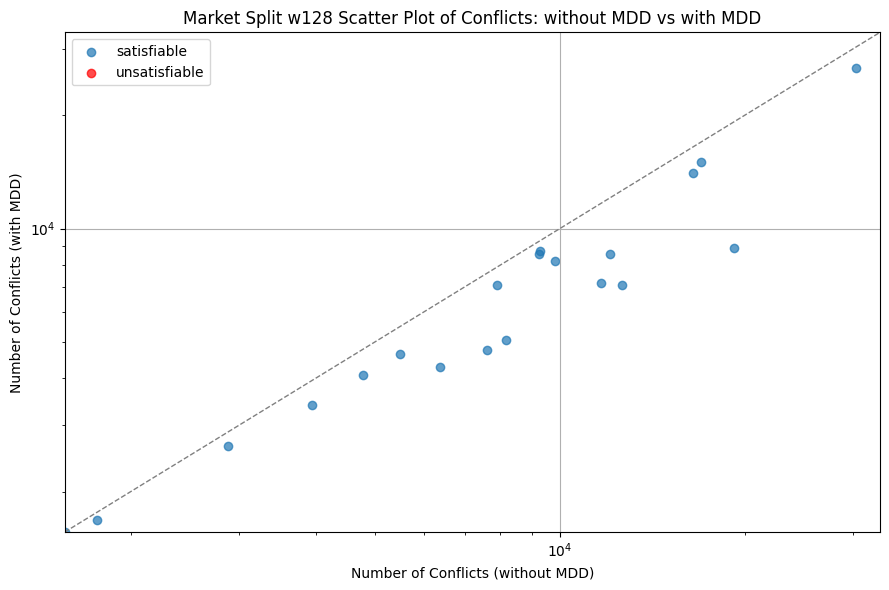

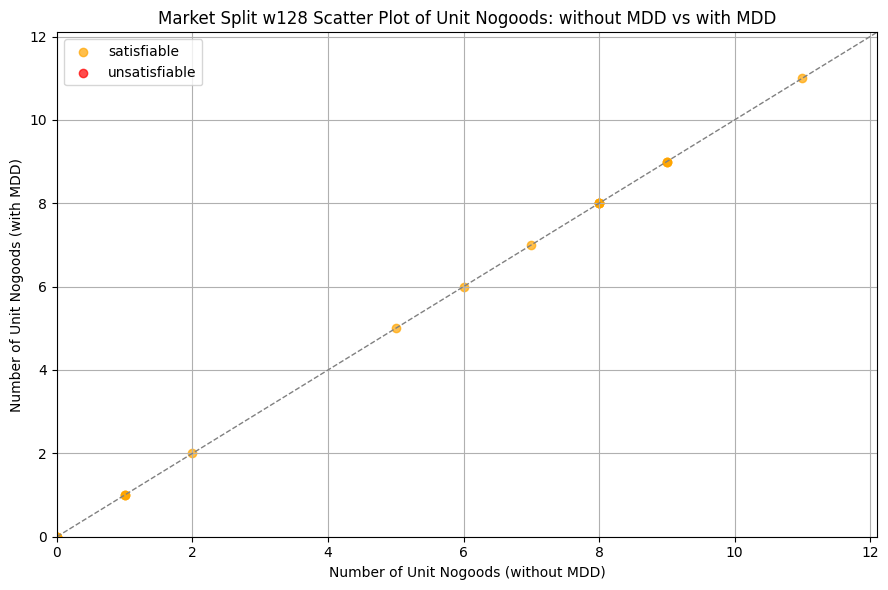

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


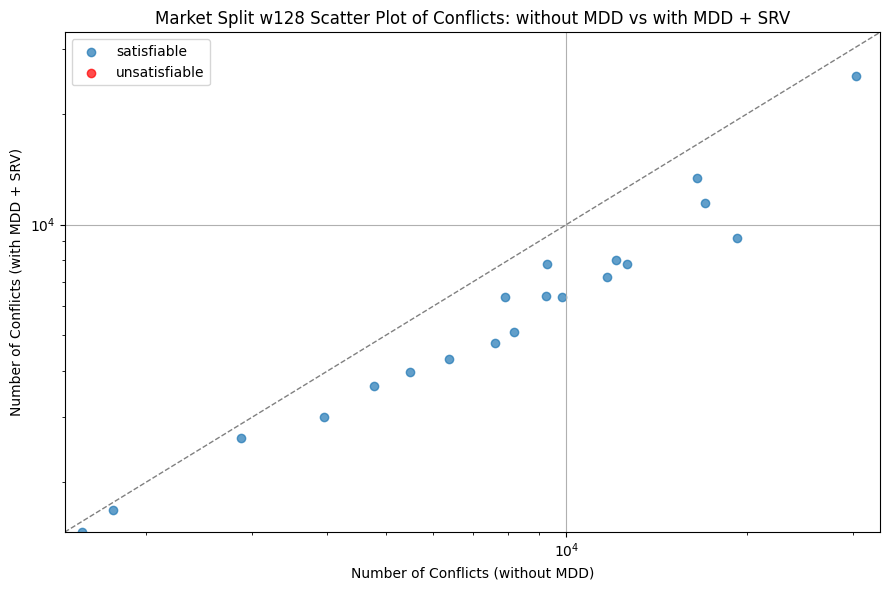

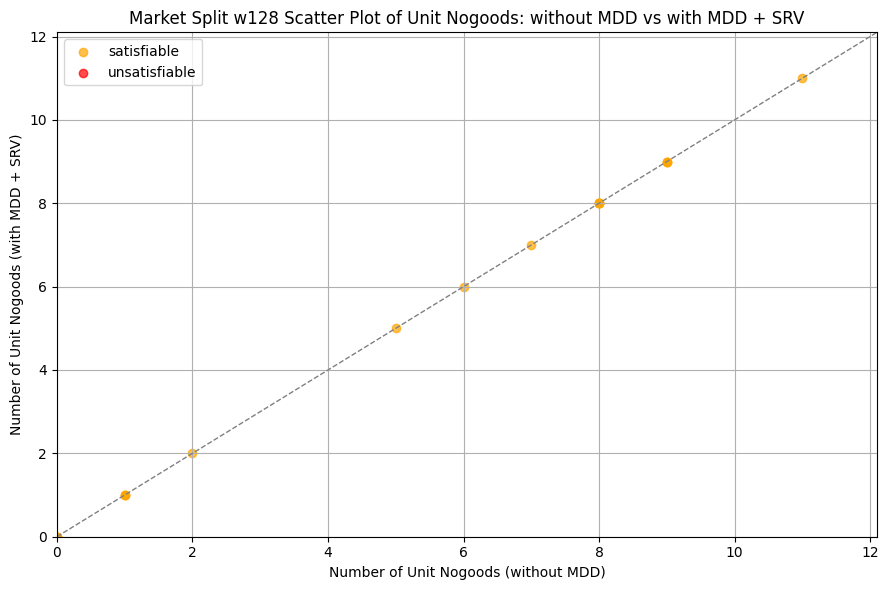

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


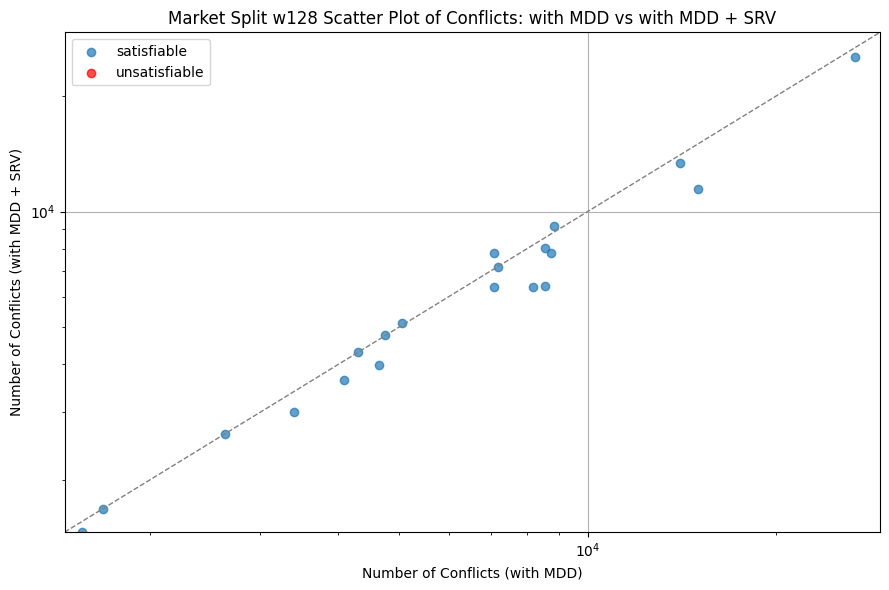

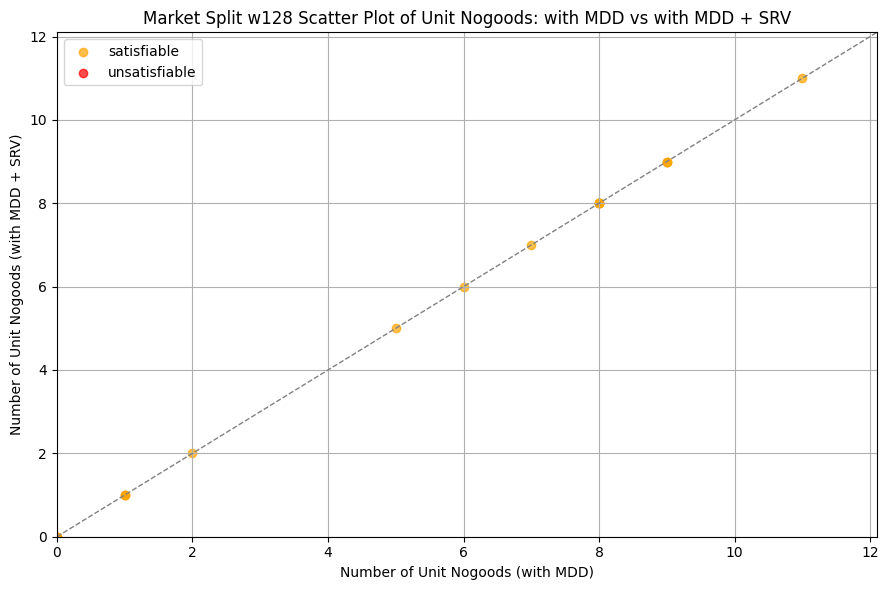

In [11]:
## Max width 128 - Market Split
file_128 = 'experiment_1_maxwidth_128/marketsplit_dd_disabled.csv'
file_128_with_mdd = 'experiment_1_maxwidth_128/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd,'without MDD', 'with MDD', 'Market Split w128', (9,6))
file_128 = 'experiment_1_maxwidth_128/marketsplit_dd_disabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd_srv,'without MDD', 'with MDD + SRV', 'Market Split w128', (9,6))
file_128_with_mdd = 'experiment_1_maxwidth_128/marketsplit_dd_enabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_128_with_mdd, file_128_with_mdd_srv,'with MDD', 'with MDD + SRV', 'Market Split w128', (9,6))
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/marketsplit_srv.csv'
file_128_with_mdd_srv_branchfirst = 'experiment_1_maxwidth_128/marketsplit_srv_branch_first.csv'
# plot_conflicts_and_nogoods(file_128_with_mdd_srv, file_128_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first + intersect all', 'Market Split', (9,6))

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


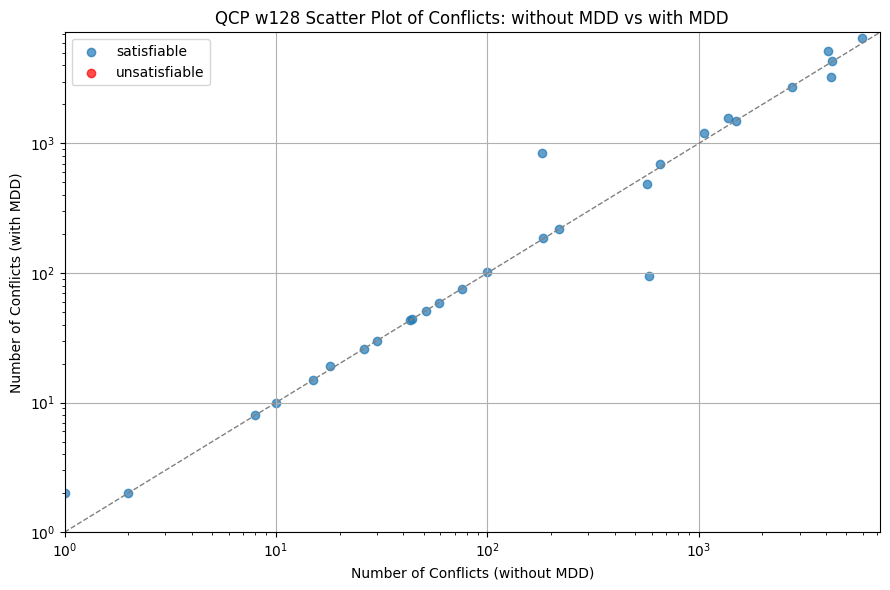

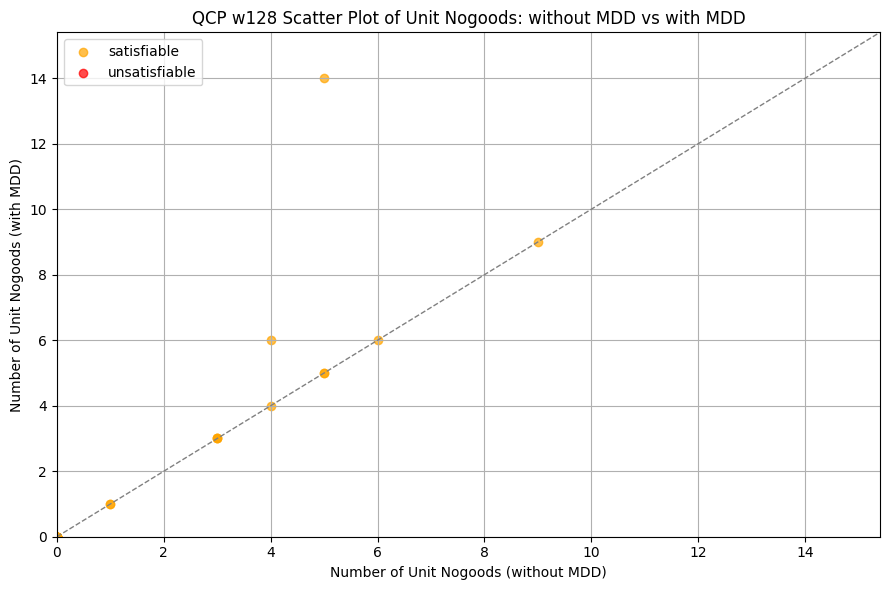

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


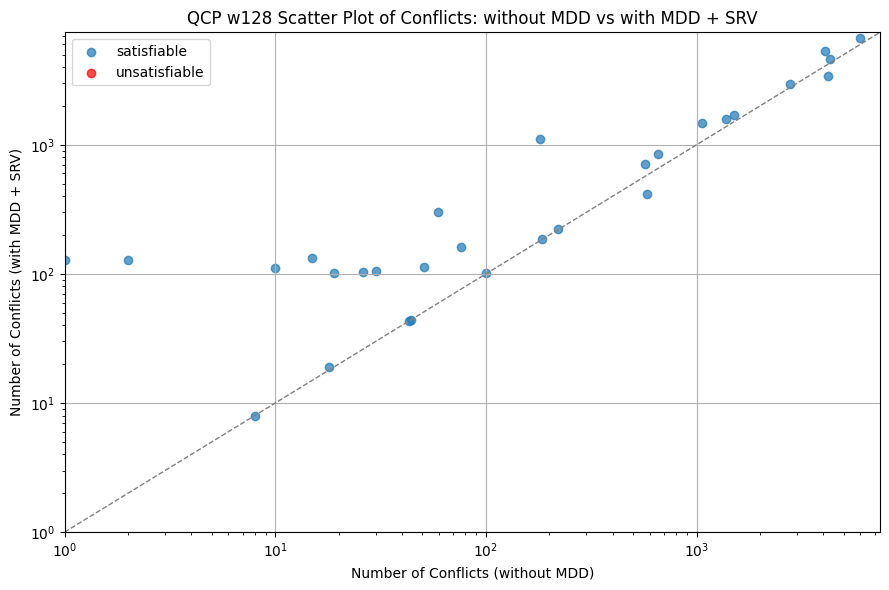

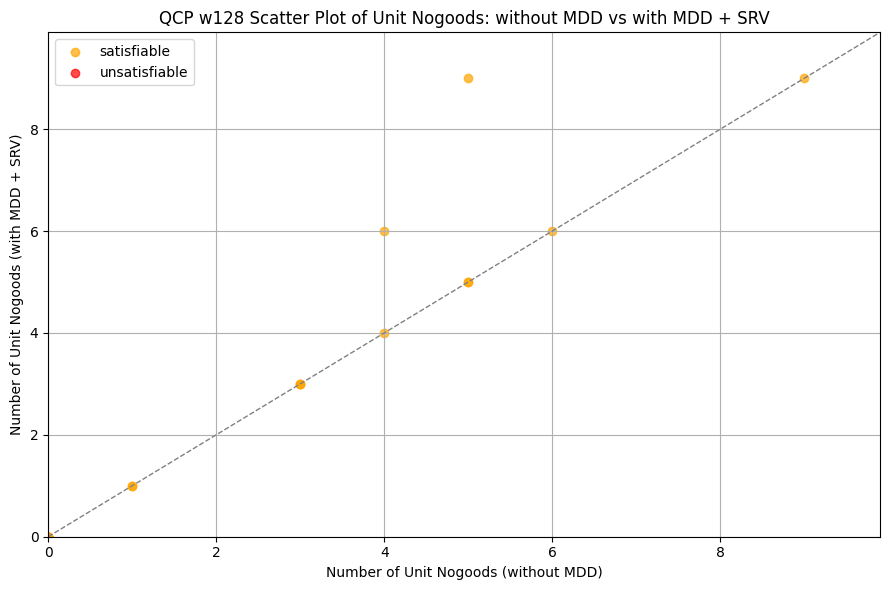

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


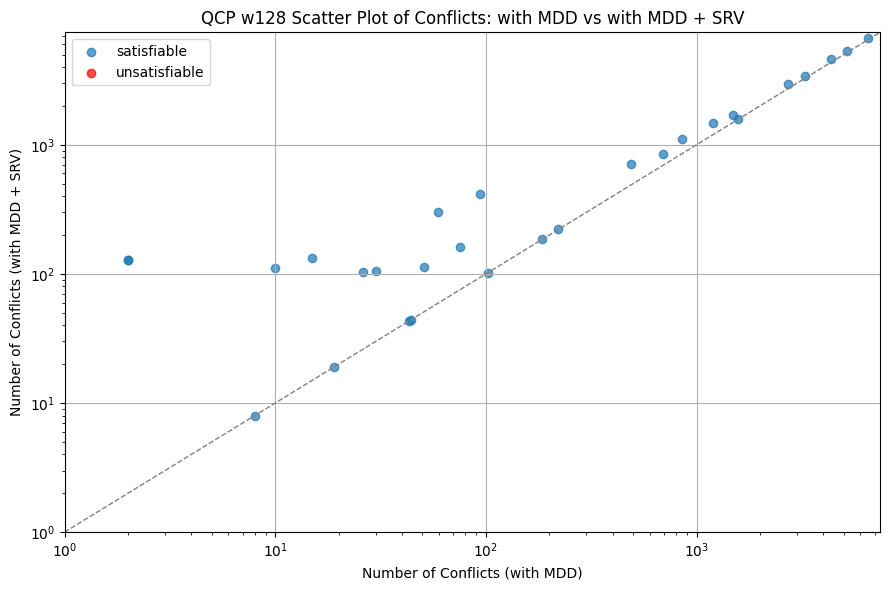

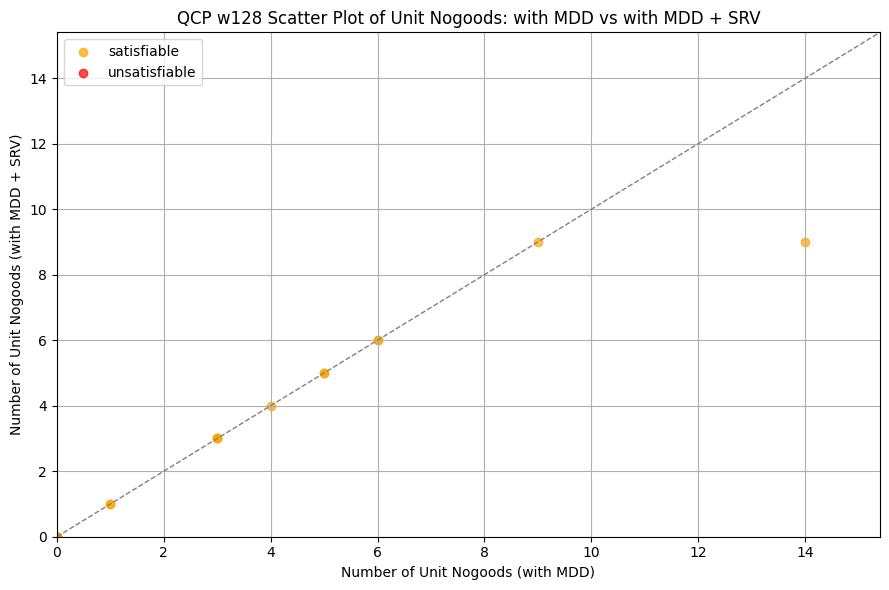

In [12]:
## Max width 128 - QCP
file_128 = 'experiment_1_maxwidth_128/qcp_disabled.csv'
file_128_with_mdd = 'experiment_1_maxwidth_128/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd,'without MDD', 'with MDD', 'QCP w128', (9,6))
file_128 = 'experiment_1_maxwidth_128/qcp_disabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/qcp_srv.csv'
plot_conflicts_and_nogoods(file_128, file_128_with_mdd_srv,'without MDD', 'with MDD + SRV', 'QCP w128', (9,6))
file_128_with_mdd = 'experiment_1_maxwidth_128/qcp_dd_enabled.csv'
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/qcp_srv.csv'
plot_conflicts_and_nogoods(file_128_with_mdd, file_128_with_mdd_srv,'with MDD', 'with MDD + SRV', 'QCP w128', (9,6))
file_128_with_mdd_srv = 'experiment_1_maxwidth_128/qcp_srv.csv'
file_128_with_mdd_srv_branchfirst = 'experiment_1_maxwidth_128/qcp_srv_branch_first.csv'
# plot_conflicts_and_nogoods(file_128_with_mdd_srv, file_128_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first + intersect all', 'QCP', (9,6))

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


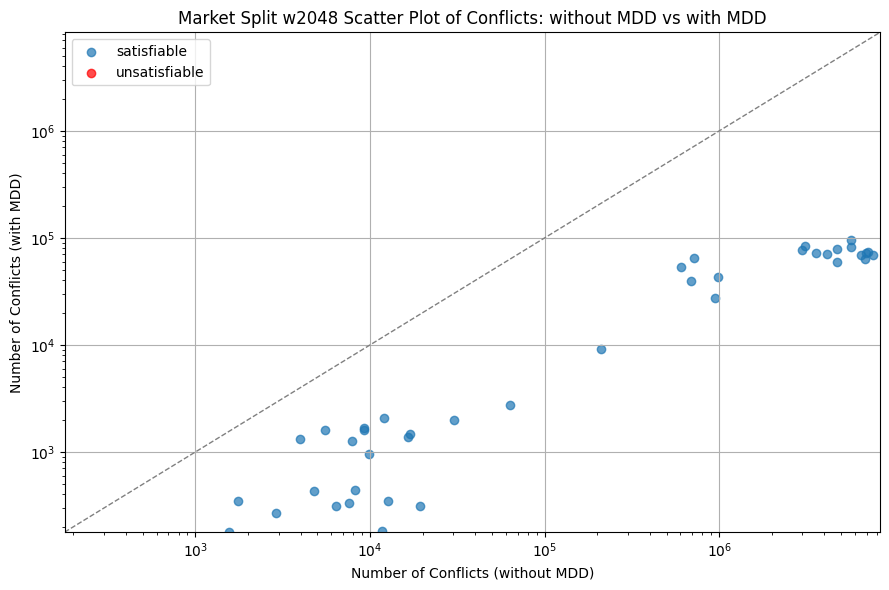

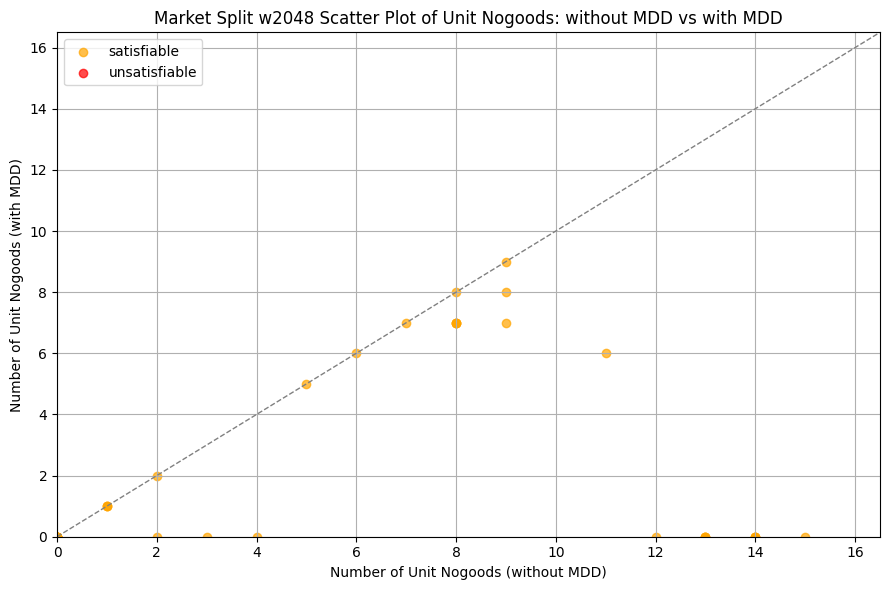

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


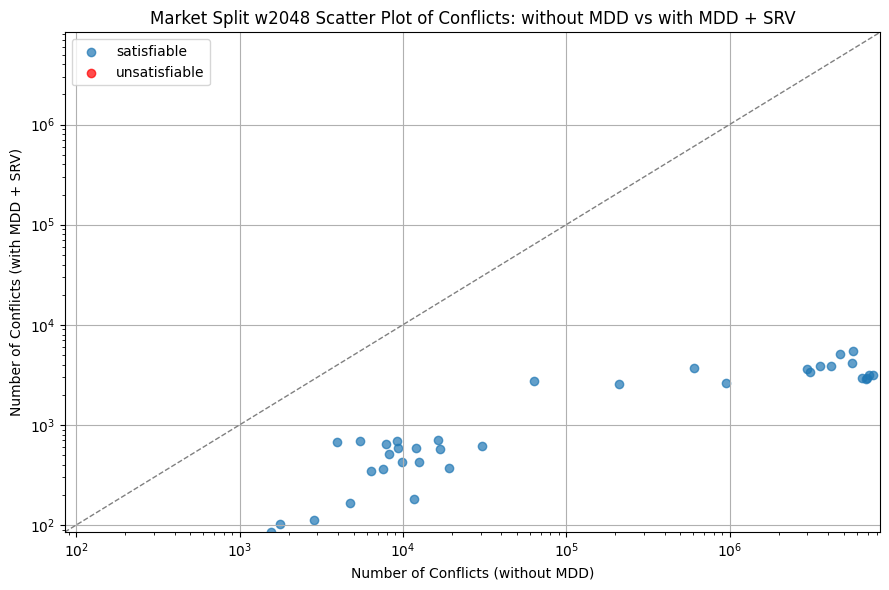

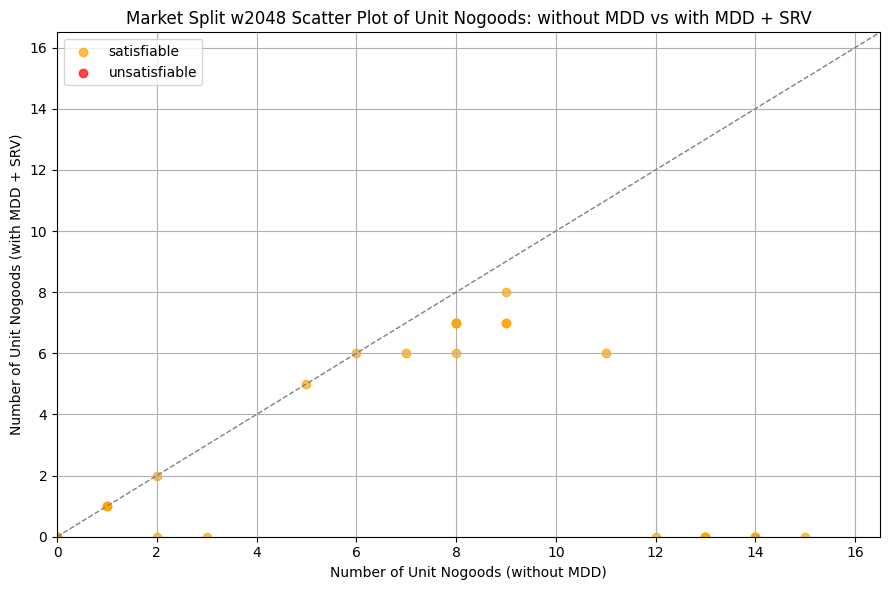

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


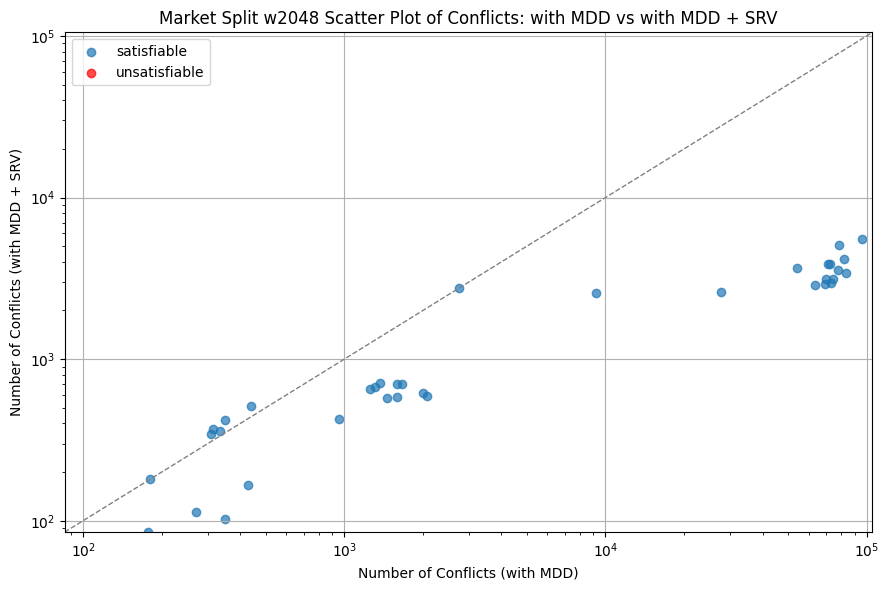

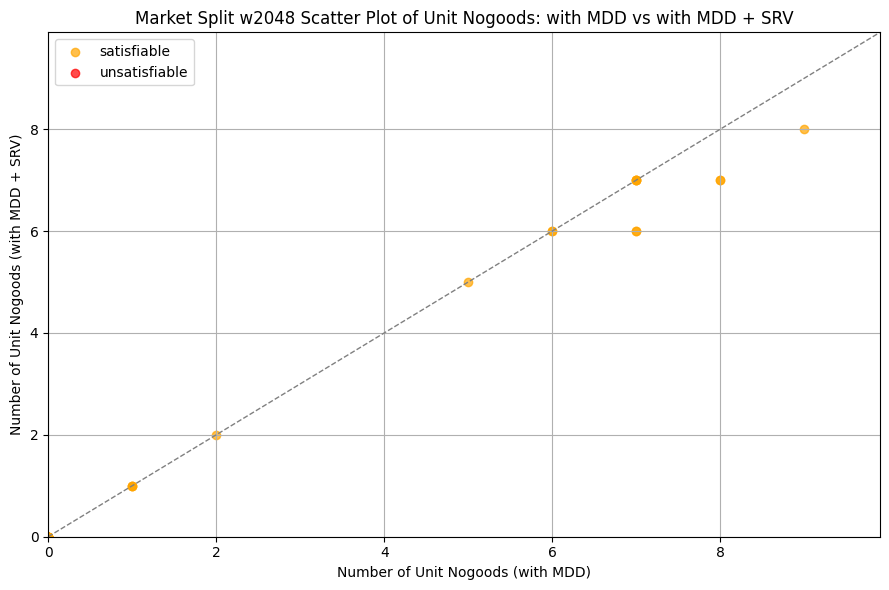

In [13]:
## Max width 2048 - Market Split
file_2048 = 'experiment_1_maxwidth_2048/marketsplit_dd_disabled.csv'
file_2048_with_mdd = 'experiment_1_maxwidth_2048/marketsplit_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'Market Split w2048', (9,6))
file_2048 = 'experiment_1_maxwidth_2048/marketsplit_dd_disabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'Market Split w2048', (9,6))
file_2048_with_mdd = 'experiment_1_maxwidth_2048/marketsplit_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/marketsplit_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'Market Split w2048', (9,6))
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/marketsplit_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_1_maxwidth_2048/marketsplit_srv_branch_first.csv'
# plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first + intersect all', 'Market Split', (9,6))

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


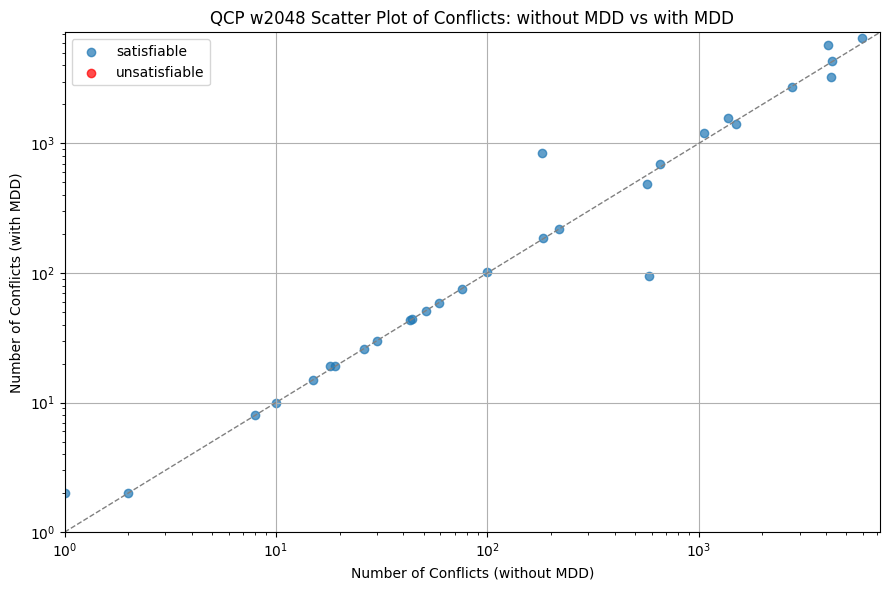

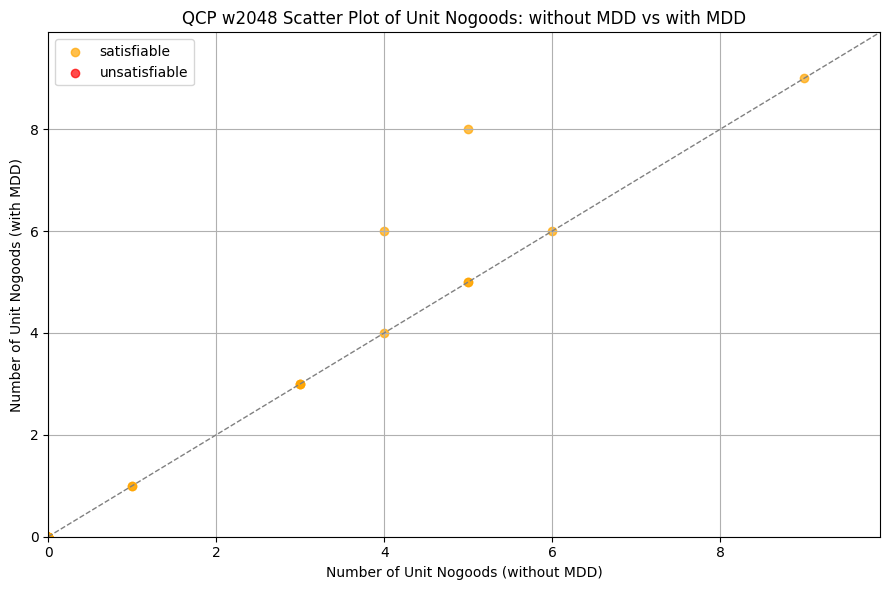

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


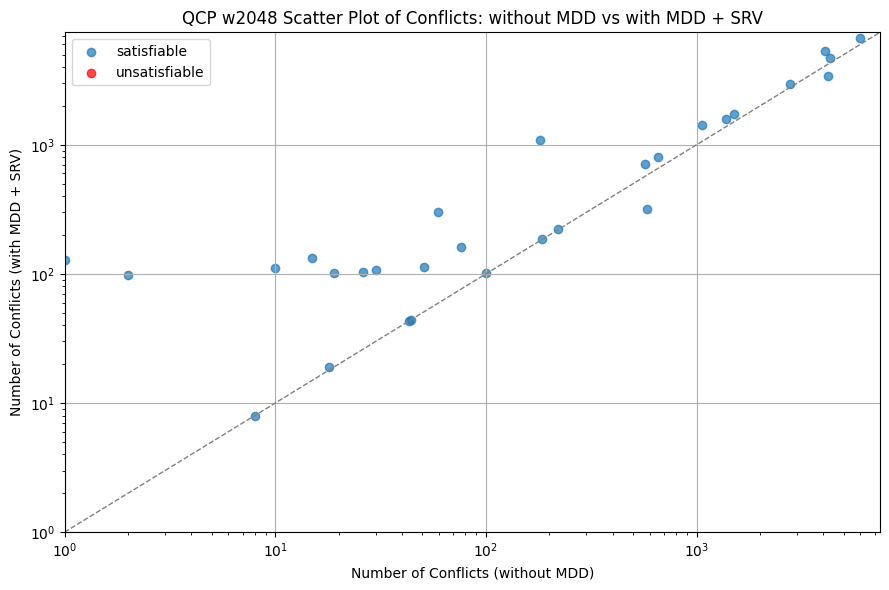

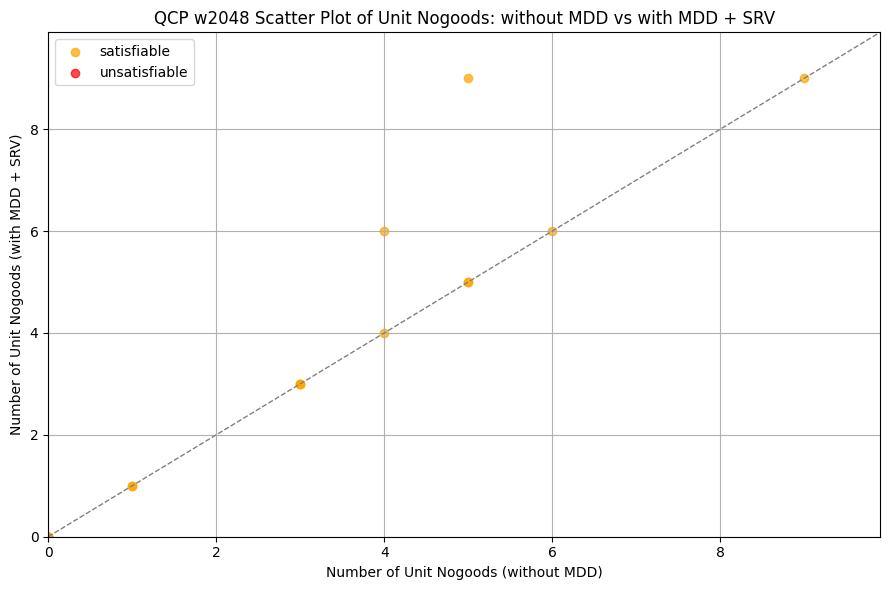

Series([], Name: Filename, dtype: object)
Series([], Name: Filename, dtype: object)


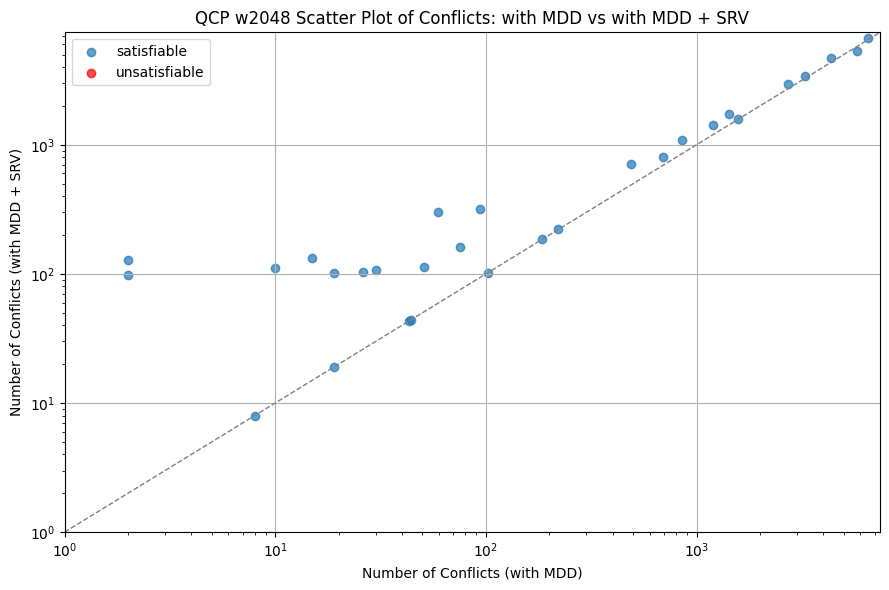

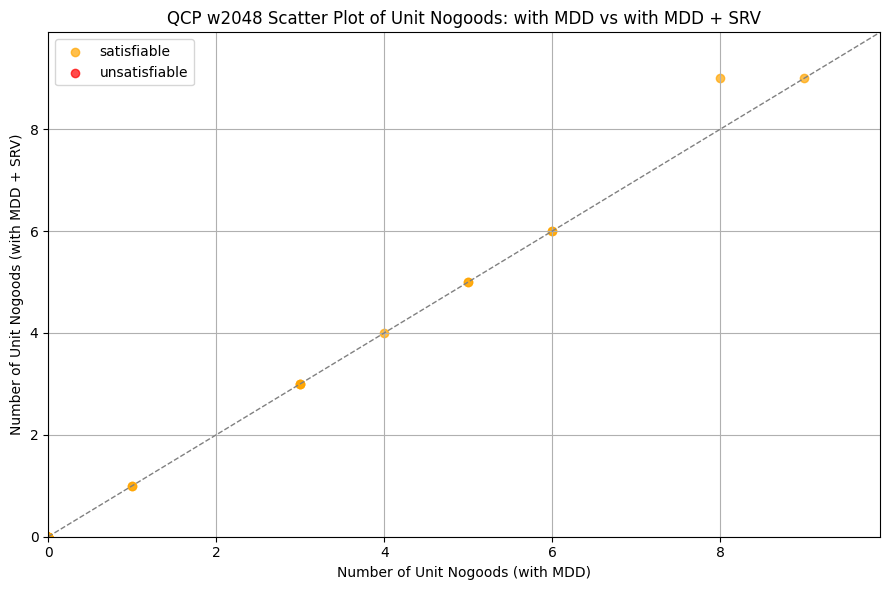

In [14]:
## Max width 2048 - QCP
file_2048 = 'experiment_1_maxwidth_2048/qcp_disabled.csv'
file_2048_with_mdd = 'experiment_1_maxwidth_2048/qcp_dd_enabled.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd,'without MDD', 'with MDD', 'QCP w2048', (9,6))
file_2048 = 'experiment_1_maxwidth_2048/qcp_disabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048, file_2048_with_mdd_srv,'without MDD', 'with MDD + SRV', 'QCP w2048', (9,6))
file_2048_with_mdd = 'experiment_1_maxwidth_2048/qcp_dd_enabled.csv'
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
plot_conflicts_and_nogoods(file_2048_with_mdd, file_2048_with_mdd_srv,'with MDD', 'with MDD + SRV', 'QCP w2048', (9,6))
file_2048_with_mdd_srv = 'experiment_1_maxwidth_2048/qcp_srv.csv'
file_2048_with_mdd_srv_branchfirst = 'experiment_1_maxwidth_2048/qcp_srv_branch_first.csv'
# plot_conflicts_and_nogoods(file_2048_with_mdd_srv, file_2048_with_mdd_srv_branchfirst,'with MDD + SRV', 'with MDD + SRV + branch SRV first + intersect all', 'QCP', (9,6))